# Drogued drifter in an idealized flow

A drogued drifter is a surface buoy connected by a rigid pole to a subsurface drogue (a vane or cross-shaped sail). The drogue anchors the drifter to a target depth so that the buoy tracks currents at that depth rather than being blown by wind and surface waves. But the buoy still feels surface drag, so the actual drift velocity is a compromise between the surface current (acting on the buoy) and the deeper current (acting on the drogue). The `DroguedDrifter` model computes this compromise from the full equations of motion.

This notebook demonstrates the drogued drifter model coupled to [Parcels v4](https://github.com/OceanParcels/parcels) in a synthetic 3D velocity field. We compare three types of Lagrangian particles:

1. **Drogued drifters**: advected at the steady-state drift velocity of the buoy+drogue system.
2. **Surface point particles**: advected at z = 0 (the fastest current).
3. **Drogue-depth point particles**: advected at the drogue depth.

The drogued drifter should travel at an intermediate speed, between the surface and drogue-depth point particles.

## Imports

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode, Variable
from parcels._core.statuscodes import FieldOutOfBoundError
from parcels.kernels import AdvectionRK4
from scipy.special import erf

from drogued_drifters.drifter import DroguedDrifter

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_92058/3140101049.py:7: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode, Variable


## Physical parameters

The velocity field consists of two opposing meandering jets on a flat Cartesian grid. The current decays exponentially with depth and rotates clockwise (Ekman-like), creating vertical shear that the drogued drifter model must resolve.

**Flow parameters:**
- `U_0`: peak surface current speed.
- `H`: e-folding depth for vertical decay. At depth `H`, the current is reduced to ~37% of its surface value.
- `L_Y`: Gaussian half-width of each jet.
- `JET_SEP`: distance between jet centres.
- `A_MEANDER`, `K_MEANDER`: amplitude and wavenumber of the sinusoidal jet meander.

**Drifter parameter:**
- `DROGUE_DEPTH`: depth of the drogue below the surface (3 m for the Callies et al. drifter design).

In [2]:
U_0 = 2.0              # peak surface current [m/s]
H = 3.0                # e-folding depth [m]
L_Y = 5_000.0          # jet half-width [m]
JET_SEP = 12_000.0     # separation between jet centres [m]
A_MEANDER = 3_000.0    # meander amplitude [m]
K_MEANDER = 2 * np.pi / 30_000.0  # meander wavenumber [1/m]
MEANDER_PHASE = np.pi / 3         # phase offset between jets

ROTATION_DEG_0 = 20.0    # rotation at surface [deg/e-fold]
ROTATION_DEG_DEEP = 90.0 # rotation at depth [deg/e-fold]
Z_ROT = 5.0              # depth scale for rotation increase [m]

DROGUE_DEPTH = 3.0  # drogue depth [m]

## Build the velocity field

We use a **streamfunction** to prescribe the surface flow — not because non-divergence is important here, but because it is a convenient way to define a smooth, interesting flow pattern with meandering jets.

Each jet has a Gaussian cross-section with sinusoidal meanders:

$$\psi_i(x, y) = -U_i \, L_Y \, \frac{\sqrt{\pi}}{2} \, \operatorname{erf}\!\left(\frac{y - y_{c,i}(x)}{L_Y}\right)$$

where $y_{c,i}(x)$ is the meandering centreline. The velocity components follow from $U_s = -\partial\psi/\partial y$ and $V_s = \partial\psi/\partial x$.

The two jets flow in opposite directions (jet 1 eastward, jet 2 westward) and have different meander phases. The surface velocity decays exponentially with depth and rotates clockwise, mimicking Ekman dynamics:

$$\begin{pmatrix} U \\ V \end{pmatrix} = e^{-z/H} \begin{pmatrix} \cos\alpha(z) & -\sin\alpha(z) \\ \sin\alpha(z) & \cos\alpha(z) \end{pmatrix} \begin{pmatrix} U_s \\ V_s \end{pmatrix}$$

where the rotation rate increases with depth:

$$\alpha(z) = -\frac{z}{H}\left[\alpha_0 + (\alpha_\infty - \alpha_0)\left(1 - e^{-z/z_r}\right)\right]$$

with $\alpha_0 = 20°$/e-fold at the surface increasing to $\alpha_\infty = 90°$/e-fold at depth, over a scale $z_r = 5$ m.

In [3]:
NX, NY, NZ = 300, 150, 20
x = np.linspace(-200_000, 200_000, NX)
y = np.linspace(-50_000, 50_000, NY)
depth = np.linspace(0, 100, NZ)
time = np.array([0.0])

Z, Y, X = np.meshgrid(depth, y, x, indexing="ij")

# Meandering jet centrelines
y_c1 = JET_SEP / 2 + A_MEANDER * np.sin(K_MEANDER * X)
y_c2 = -JET_SEP / 2 + A_MEANDER * np.sin(K_MEANDER * X + MEANDER_PHASE)
dy_c1_dx = A_MEANDER * K_MEANDER * np.cos(K_MEANDER * X)
dy_c2_dx = A_MEANDER * K_MEANDER * np.cos(K_MEANDER * X + MEANDER_PHASE)

eta1 = (Y - y_c1) / L_Y
eta2 = (Y - y_c2) / L_Y

# Surface velocity from streamfunction derivatives
U_surface = U_0 * np.exp(-eta1**2) - U_0 * np.exp(-eta2**2)
V_surface = U_0 * np.exp(-eta1**2) * dy_c1_dx - U_0 * np.exp(-eta2**2) * dy_c2_dx

# Depth decay with Ekman-like rotation
rot_deg_z = ROTATION_DEG_0 + (ROTATION_DEG_DEEP - ROTATION_DEG_0) * (1 - np.exp(-Z / Z_ROT))
angle = -np.radians(rot_deg_z) * Z / H
decay = np.exp(-Z / H)

U_data = (U_surface * decay * np.cos(angle) - V_surface * decay * np.sin(angle))[np.newaxis, ...]
V_data = (U_surface * decay * np.sin(angle) + V_surface * decay * np.cos(angle))[np.newaxis, ...]

# Build xarray Dataset with SGRID metadata
ds = xr.Dataset(
    {
        "U": (["time", "depth", "y", "x"], U_data),
        "V": (["time", "depth", "y", "x"], V_data),
        "grid": xr.DataArray(
            data=0,
            attrs={
                "cf_role": "grid_topology",
                "topology_dimension": 2,
                "node_dimensions": "x y",
                "face_dimensions": "x:x (padding: none) y:y (padding: none)",
                "vertical_dimensions": "depth:depth (padding: none)",
                "node_coordinates": "x y",
            },
        ),
    },
    coords={
        "x": ("x", x, {"axis": "X"}),
        "y": ("y", y, {"axis": "Y"}),
        "depth": ("depth", depth, {"axis": "Z"}),
        "time": ("time", time, {"axis": "T"}),
    },
)

fieldset = FieldSet.from_sgrid_conventions(ds, mesh="flat")
fieldset.add_constant("drogue_depth", DROGUE_DEPTH)

## Define the drogued drifter kernel

The coupling strategy:

1. At each Parcels timestep, sample UV at the surface (z=0, acting on the buoy) and at the drogue depth (z=3m, acting on the drogue).
2. Feed both velocity pairs to `DroguedDrifter.get_final_drift_batch`, which solves the full equations of motion to steady state in a single vectorized `solve_ivp` call for all particles.
3. Apply the resulting drift velocity as a forward Euler step via the Parcels `dlon`/`dlat` accumulators.

The solver is warm-started from the previous steady state, so convergence is almost immediate when the flow changes slowly.

Note: the drogue velocity is sampled at a fixed depth (the pole length), not at the actual effective drogue depth `z_eff`. For small pole tilt this is a good approximation.

**Parcels v4 output**: We store drogued drifter trajectories in a Python dict because the Parcels v4 alpha zarr writer has a known bug with custom kernels. The point particle runs use the standard `ParticleFile` output.

In [4]:
DrifterParticle = Particle.add_variable(Variable("z_eff", dtype=np.float64, initial=0.0))

dd = DroguedDrifter()
_warm_state = {}

drifter_trajectory = {"lon": [], "lat": [], "time": [], "z_eff": []}


def DroguedDrifterKernel(particles, fieldset):
    """Advect particles at the steady-state drift velocity of a buoy+drogue."""
    drogue_depth = fieldset.drogue_depth

    n = len(np.asarray(particles.lon))
    z_surface = np.zeros(n)
    z_drogue = np.full(n, drogue_depth)
    try:
        (u_b, v_b) = fieldset.UV[
            particles.time, z_surface, particles.lat, particles.lon, particles
        ]
        (u_d, v_d) = fieldset.UV[
            particles.time, z_drogue, particles.lat, particles.lon, particles
        ]
    except FieldOutOfBoundError:
        particles.state = StatusCode.Delete
        return

    u_b, v_b = np.asarray(u_b), np.asarray(v_b)
    u_d, v_d = np.asarray(u_d), np.asarray(v_d)
    dt = np.asarray(particles.dt)
    lon_arr = np.asarray(particles.lon)
    lat_arr = np.asarray(particles.lat)
    time_arr = np.asarray(particles.time)

    n = len(u_b)
    y0_warm = _warm_state.get("Y") if _warm_state.get("n") == n else None
    xd_drift, yd_drift, theta_final, Y_final = dd.get_final_drift_batch(
        U_b=u_b, V_b=v_b, U_d=u_d, V_d=v_d, y0=y0_warm,
    )
    _warm_state["Y"] = Y_final
    _warm_state["n"] = n
    z_eff = -dd.l * np.cos(theta_final)

    particles.dlon += xd_drift * dt
    particles.dlat += yd_drift * dt
    particles.z_eff = z_eff

    drifter_trajectory["lon"].append(lon_arr.copy())
    drifter_trajectory["lat"].append(lat_arr.copy())
    drifter_trajectory["time"].append(time_arr.copy())
    drifter_trajectory["z_eff"].append(z_eff.copy())


def DeleteOOB(particles, fieldset):
    """Convert out-of-bounds errors to Delete status."""
    state = np.asarray(particles.state)
    oob = (state == StatusCode.ErrorOutOfBounds) | (state == StatusCode.ErrorThroughSurface)
    if np.any(oob):
        particles.state = np.where(oob, StatusCode.Delete, state)

## Run simulations

We release particles in a grid spanning both jets at several x-positions. Three simulations run the same initial positions with:

1. The drogued drifter kernel (buoy+drogue coupling).
2. Parcels' built-in `AdvectionRK4` at z=0 (surface point particles).
3. `AdvectionRK4` at z=3m (drogue-depth point particles).

Note: the drogued drifter kernel uses forward Euler advection while the
point particles use RK4. For the 5-minute timestep and flow speeds here,
the time-stepping error is small compared to the physics differences.

In [5]:
DT = 300.0           # timestep: 5 min [s]
RUNTIME = 8 * 3600.0 # total: 8 hours [s]
OUTPUTDT = 300.0     # output every 5 min

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Release grid: 5 x-positions, 10 y-positions spanning both jets
_lats = np.linspace(-JET_SEP / 2 - 2 * L_Y, JET_SEP / 2 + 2 * L_Y, 10)
_x_positions = np.linspace(5_000, 25_000, 5)
_lon_grid, _lat_grid = np.meshgrid(_x_positions, _lats)
release_lons = _lon_grid.ravel().tolist()
release_lats = _lat_grid.ravel().tolist()
n_particles = len(release_lats)

In [6]:
pset_drifter = ParticleSet(
    fieldset=fieldset,
    pclass=DrifterParticle,
    lon=release_lons,
    lat=release_lats,
    z=[0] * n_particles,
)
pset_drifter.execute(
    kernels=[DroguedDrifterKernel, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    verbose_progress=False,
)

  0%|          | 0/28800.0 [00:00<?, ?it/s]

Integration time: 0.0:   0%|          | 0/28800.0 [00:00<?, ?it/s]

Integration time: 0 seconds:   0%|          | 0/28800.0 [00:10<?, ?it/s]

Integration time: 0 seconds: 100%|██████████| 28800.0/28800.0 [00:10<00:00, 2780.88it/s]

Integration time: 0 seconds: 100%|██████████| 28800.0/28800.0 [00:10<00:00, 2780.80it/s]

In [7]:
surface_store = str(OUTPUT_DIR / "surface_tracer.zarr")
shutil.rmtree(surface_store, ignore_errors=True)

pset_surface = ParticleSet(
    fieldset=fieldset,
    pclass=Particle,
    lon=release_lons,
    lat=release_lats,
    z=[0] * n_particles,
)
pset_surface.execute(
    kernels=[AdvectionRK4, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=surface_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/output/surface_tracer.zarr


  0%|          | 0/28800.0 [00:00<?, ?it/s]

Integration time: 0.0:   0%|          | 0/28800.0 [00:00<?, ?it/s]

Integration time: 0 seconds:   0%|          | 0/28800.0 [00:00<?, ?it/s]

Integration time: 0 seconds:   0%|          | 0.0/28800.0 [00:00<?, ?it/s]

...

Integration time: 27600 seconds:  96%|█████████▌| 27600.0/28800.0 [00:01<00:00, 27062.38it/s]

Integration time: 27900 seconds:  97%|█████████▋| 27900.0/28800.0 [00:01<00:00, 27062.38it/s]

Integration time: 28200 seconds:  98%|█████████▊| 28200.0/28800.0 [00:01<00:00, 27062.38it/s]

Integration time: 28500 seconds:  99%|█████████▉| 28500.0/28800.0 [00:01<00:00, 27062.38it/s]

Integration time: 28500 seconds: 100%|██████████| 28800.0/28800.0 [00:01<00:00, 27308.15it/s]

In [8]:
drogue_store = str(OUTPUT_DIR / "drogue_depth_tracer.zarr")
shutil.rmtree(drogue_store, ignore_errors=True)

pset_drogue = ParticleSet(
    fieldset=fieldset,
    pclass=Particle,
    lon=release_lons,
    lat=release_lats,
    z=[DROGUE_DEPTH] * n_particles,
)
pset_drogue.execute(
    kernels=[AdvectionRK4, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=drogue_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/output/drogue_depth_tracer.zarr


  0%|          | 0/28800.0 [00:00<?, ?it/s]

Integration time: 0.0:   0%|          | 0/28800.0 [00:00<?, ?it/s]

Integration time: 0 seconds:   0%|          | 0/28800.0 [00:00<?, ?it/s]

Integration time: 0 seconds:   0%|          | 0.0/28800.0 [00:00<?, ?it/s]

...

Integration time: 27900 seconds:  97%|█████████▋| 27900.0/28800.0 [00:01<00:00, 26380.77it/s]

Integration time: 28200 seconds:  98%|█████████▊| 28200.0/28800.0 [00:01<00:00, 26380.77it/s]

Integration time: 28500 seconds:  99%|█████████▉| 28500.0/28800.0 [00:01<00:00, 26380.77it/s]

Integration time: 28500 seconds: 100%|██████████| 28800.0/28800.0 [00:01<00:00, 26058.59it/s]

Integration time: 28500 seconds: 100%|██████████| 28800.0/28800.0 [00:01<00:00, 26396.67it/s]

## Plot trajectories

Streamfunction contours show the flow structure. Surface point particles (red) travel furthest, drogue-depth point particles (green) travel least, and the drogued drifters (blue, dashed) fall in between.

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_92058/1105407944.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_surface = xr.open_zarr(surface_store)
/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_92058/1105407944.py:2: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype

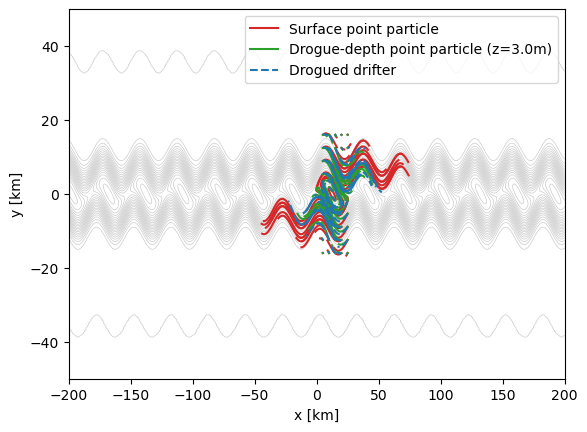

In [9]:
ds_surface = xr.open_zarr(surface_store)
ds_drogue = xr.open_zarr(drogue_store)

# Streamfunction contours for flow context
x_plot = np.linspace(x.min(), x.max(), 400)
y_plot = np.linspace(y.min(), y.max(), 400)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)
yc1_plot = JET_SEP / 2 + A_MEANDER * np.sin(K_MEANDER * X_plot)
yc2_plot = -JET_SEP / 2 + A_MEANDER * np.sin(K_MEANDER * X_plot + MEANDER_PHASE)
C_psi = U_0 * L_Y * np.sqrt(np.pi) / 2
psi = -C_psi * erf((Y_plot - yc1_plot) / L_Y) + C_psi * erf((Y_plot - yc2_plot) / L_Y)

fig, ax = plt.subplots()
ax.contour(X_plot / 1000, Y_plot / 1000, psi, levels=25, colors="0.8", linewidths=0.5)

for i in range(ds_surface.sizes["trajectory"]):
    lon_i, lat_i = ds_surface.lon.values[i, :], ds_surface.lat.values[i, :]
    valid = np.isfinite(lon_i)
    ax.plot(lon_i[valid] / 1000, lat_i[valid] / 1000, color="tab:red",
            label="Surface point particle" if i == 0 else None)

for i in range(ds_drogue.sizes["trajectory"]):
    lon_i, lat_i = ds_drogue.lon.values[i, :], ds_drogue.lat.values[i, :]
    valid = np.isfinite(lon_i)
    ax.plot(lon_i[valid] / 1000, lat_i[valid] / 1000, color="tab:green",
            label=f"Drogue-depth point particle (z={DROGUE_DEPTH}m)" if i == 0 else None)

if drifter_trajectory["lon"]:
    n0 = len(drifter_trajectory["lon"][0])
    full_steps = [i for i, arr in enumerate(drifter_trajectory["lon"]) if len(arr) == n0]
    if full_steps:
        d_lon = np.array([drifter_trajectory["lon"][i] for i in full_steps])
        d_lat = np.array([drifter_trajectory["lat"][i] for i in full_steps])
        for i in range(n0):
            ax.plot(d_lon[:, i] / 1000, d_lat[:, i] / 1000, color="tab:blue", ls="--",
                    label="Drogued drifter" if i == 0 else None)

ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.legend()
plt.show()

## Effective drogue depth

The **effective drogue depth** $z_\text{eff} = -l \cos\theta$ is the vertical projection of the pole. When the surface and drogue currents are aligned, the pole hangs nearly vertical and $z_\text{eff} \approx l$ (full drogue depth). When vertical shear is strong and the currents oppose each other, the pole tilts and $z_\text{eff}$ decreases.

This diagnostic reveals how the flow structure affects the drifter geometry.

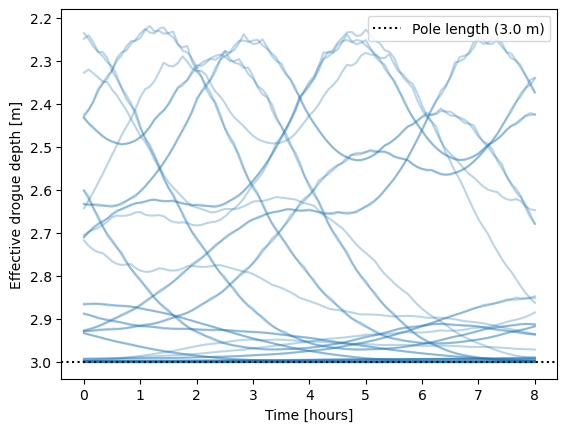

In [10]:
if drifter_trajectory["z_eff"] and full_steps:
    d_zeff = np.array([drifter_trajectory["z_eff"][i] for i in full_steps])
    d_time = np.array([drifter_trajectory["time"][i] for i in full_steps])

    fig, ax = plt.subplots()
    time_hours = d_time[:, 0] / 3600
    for i in range(n0):
        ax.plot(time_hours, d_zeff[:, i], color="tab:blue", alpha=0.3)

    ax.axhline(DROGUE_DEPTH, color="k", ls=":", label=f"Pole length ({DROGUE_DEPTH} m)")
    ax.set_xlabel("Time [hours]")
    ax.set_ylabel("Effective drogue depth [m]")
    ax.invert_yaxis()
    ax.legend()
    plt.show()

## Summary

- **Surface point particles** travel fastest, following the strong surface jets.
- **Drogue-depth point particles** travel slowest, experiencing weaker and rotated currents at depth.
- **Drogued drifters** travel at an intermediate velocity that reflects the mechanical coupling between the buoy (surface drag) and drogue (subsurface drag).
- The **effective drogue depth** varies across the flow: in regions of strong shear (jet cores), the pole tilts more and the effective depth is reduced.